# Proyek Analisis Data: E-Commerce Public Dataset

- **Nama:** Muhammad Alif Aditya
- **Email:** muhammadalifaditya92@gmail.com
- **ID Dicoding:** alif aditya

## Tujuan Proyek
Proyek ini bertujuan menganalisis data transaksi e-commerce untuk menemukan pola penjualan, perilaku pelanggan, dan faktor operasional yang memengaruhi kepuasan pelanggan. Hasil analisis kemudian akan dirangkum dalam dashboard interaktif menggunakan Streamlit.


## Menentukan Pertanyaan Bisnis

Berdasarkan karakteristik dataset, proyek ini akan menjawab pertanyaan bisnis berikut.

1. **Selama periode transaksi yang tersedia dalam dataset setelah proses cleaning, bagaimana tren jumlah order dan total revenue per bulan, serta kapan terjadi puncak dan titik terendah performa penjualan?**
2. **Selama periode analisis tersebut, kategori produk apa yang memberikan kontribusi terbesar terhadap total revenue dan jumlah order, serta bagaimana rata-rata review pada kategori-kategori utama itu?**
3. **Selama periode analisis tersebut, bagaimana keterlambatan pengiriman memengaruhi rata-rata review score pelanggan pada order yang berstatus delivered?**
4. **Selama periode analisis tersebut, state pelanggan mana yang memberikan kontribusi revenue terbesar, dan bagaimana perbandingan jumlah order, rata-rata review, serta persentase keterlambatan pada state-state utama??**
5. **Selama periode analisis tersebut, metode pembayaran apa yang paling sering digunakan, mana yang menghasilkan total pembayaran terbesar, dan mana yang memiliki rata-rata nilai pembayaran tertinggi?**
6. **Selama periode analisis tersebut, bagaimana segmentasi pelanggan berdasarkan Recency, Frequency, dan Monetary (RFM), dan segmen pelanggan mana yang paling bernilai untuk diprioritaskan?**
7. **Selama periode analisis tersebut, bagaimana distribusi pelanggan berdasarkan kelompok nilai belanja (manual grouping: low, medium, high spender), dan kelompok mana yang paling besar kontribusinya terhadap revenue?**
8. **Bagaimana persebaran geografis kontribusi revenue pelanggan di berbagai state, dan wilayah mana yang paling layak diprioritaskan untuk promosi dan optimasi logistik?**

Sebagai analisis lanjutan untuk memperkaya insight, proyek ini juga menambahkan:
- **RFM Analysis** untuk mengelompokkan pelanggan berdasarkan perilaku belanja.
- **Geospatial analysis sederhana** untuk melihat persebaran kontribusi pendapatan per state pelanggan.


## Import Semua Packages/Library yang Digunakan

In [1]:
%pip install pandas numpy matplotlib seaborn ipython

Note: you may need to restart the kernel to use updated packages.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display, Markdown
import os

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

PRIMARY_COLOR = "#4C78A8"
HIGHLIGHT_COLOR = "#F58518"
BASE_COLOR = "#4E79A7"
LOWLIGHT_COLOR = "#B0B0B0"

def format_currency(value):
    return f"R$ {value:,.2f}"

def format_number(value):
    return f"{int(value):,}".replace(",", ".")

def format_percent(value):
    return f"{value:.2f}%"

def highlight_first_bar(ax):
    for i, patch in enumerate(ax.patches):
        patch.set_facecolor(HIGHLIGHT_COLOR if i == 0 else PRIMARY_COLOR)

## Data Wrangling

### Gathering Data

In [3]:
customers_df = pd.read_csv("data/customers_dataset.csv")
geolocation_df = pd.read_csv("data/geolocation_dataset.csv")
order_items_df = pd.read_csv("data/order_items_dataset.csv")
order_payments_df = pd.read_csv("data/order_payments_dataset.csv")
order_reviews_df = pd.read_csv("data/order_reviews_dataset.csv")
orders_df = pd.read_csv("data/orders_dataset.csv")
product_category_df = pd.read_csv("data/product_category_name_translation.csv")
products_df = pd.read_csv("data/products_dataset.csv", sep=";")
sellers_df = pd.read_csv("data/sellers_dataset.csv")

dataset_summary = pd.DataFrame({
    "dataset": [
        "customers", "geolocation", "order_items", "order_payments",
        "order_reviews", "orders", "product_category_translation",
        "products", "sellers"
    ],
    "rows": [
        len(customers_df), len(geolocation_df), len(order_items_df), len(order_payments_df),
        len(order_reviews_df), len(orders_df), len(product_category_df), len(products_df), len(sellers_df)
    ],
    "columns": [
        customers_df.shape[1], geolocation_df.shape[1], order_items_df.shape[1], order_payments_df.shape[1],
        order_reviews_df.shape[1], orders_df.shape[1], product_category_df.shape[1], products_df.shape[1], sellers_df.shape[1]
    ]
})

dataset_summary

,dataset,rows,columns
0,customers,99441,5
1,geolocation,1000163,5
2,order_items,112650,7
3,order_payments,103886,5
4,order_reviews,99224,7
5,orders,99441,8
6,product_category_translation,71,2
7,products,32951,9
8,sellers,3095,4


**Insight:**
- Dataset utama yang digunakan pada proyek ini terdiri dari data pelanggan, pesanan, item pesanan, pembayaran, ulasan, produk, dan geolokasi.
- Struktur data tersebut sudah memadai untuk menjawab pertanyaan bisnis terkait performa penjualan, kategori produk, keterlambatan pengiriman, metode pembayaran, segmentasi pelanggan, dan persebaran geografis.
- Tahap berikutnya adalah menilai kualitas masing-masing dataset sebelum digabungkan ke dalam data analisis utama.

### Assessing Data

In [4]:
def assess_data(df, df_name):
    return pd.DataFrame({
        "dataset": [df_name] * len(df.columns),
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_values": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
        "duplicate_rows": [df.duplicated().sum()] * len(df.columns),
        "unique_values": [df[col].nunique(dropna=True) for col in df.columns]
    })

assessment_df = pd.concat([
    assess_data(customers_df, "customers"),
    assess_data(geolocation_df, "geolocation"),
    assess_data(order_items_df, "order_items"),
    assess_data(order_payments_df, "order_payments"),
    assess_data(order_reviews_df, "order_reviews"),
    assess_data(orders_df, "orders"),
    assess_data(product_category_df, "product_category_translation"),
    assess_data(products_df, "products"),
    assess_data(sellers_df, "sellers")
], ignore_index=True)

assessment_df

,dataset,column,dtype,missing_values,missing_pct,duplicate_rows,unique_values
0,customers,customer_id,str,0,0.00,0,99441
1,customers,customer_unique_id,str,0,0.00,0,96096
2,customers,customer_zip_code_prefix,int64,0,0.00,0,14994
3,customers,customer_city,str,0,0.00,0,4119
4,customers,customer_state,str,0,0.00,0,27
5,geolocation,geolocation_zip_code_prefix,int64,0,0.00,261831,19015
6,geolocation,geolocation_lat,float64,0,0.00,261831,717360
7,geolocation,geolocation_lng,float64,0,0.00,261831,717613
8,geolocation,geolocation_city,str,0,0.00,261831,8011
9,geolocation,geolocation_state,str,0,0.00,261831,27


**Insight:**
- Hasil assessment menunjukkan bahwa beberapa dataset memiliki missing values, terutama pada kolom waktu pengiriman di tabel orders dan atribut kategori/ukuran pada tabel products.
- Dataset geolocation juga memiliki jumlah baris yang sangat besar sehingga perlu diringkas agar lebih efisien saat digunakan pada analisis geografis.
- Karena itu, pada tahap cleaning akan dilakukan konversi tipe data datetime, penanganan missing values yang relevan, agregasi geolokasi, dan pembentukan dataframe analisis yang lebih rapi.

### Cleaning Data

In [32]:
# Salin dataframe mentah agar aman
orders_clean = orders_df.copy()
order_items_clean = order_items_df.copy()
order_reviews_clean = order_reviews_df.copy()
products_clean = products_df.copy()
customers_clean = customers_df.copy()
geolocation_clean = geolocation_df.copy()
product_category_clean = product_category_df.copy()

# Rapikan nama kolom
orders_clean.columns = orders_clean.columns.str.strip()
order_items_clean.columns = order_items_clean.columns.str.strip()
order_reviews_clean.columns = order_reviews_clean.columns.str.strip()
products_clean.columns = products_clean.columns.str.strip()
customers_clean.columns = customers_clean.columns.str.strip()
geolocation_clean.columns = geolocation_clean.columns.str.strip()
product_category_clean.columns = product_category_clean.columns.str.strip()

# Cek kolom penting sebelum merge
print("Kolom products_clean:", products_clean.columns.tolist())
print("Kolom product_category_clean:", product_category_clean.columns.tolist())

# Konversi kolom datetime
datetime_columns_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in datetime_columns_orders:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors="coerce")

order_items_clean["shipping_limit_date"] = pd.to_datetime(
    order_items_clean["shipping_limit_date"], errors="coerce"
)

order_reviews_clean["review_creation_date"] = pd.to_datetime(
    order_reviews_clean["review_creation_date"], errors="coerce"
)

order_reviews_clean["review_answer_timestamp"] = pd.to_datetime(
    order_reviews_clean["review_answer_timestamp"], errors="coerce"
)

# Pastikan kolom untuk merge memang ada
if "product_category_name" not in products_clean.columns:
    raise KeyError("Kolom 'product_category_name' tidak ditemukan di products_clean")

if "product_category_name" not in product_category_clean.columns:
    raise KeyError("Kolom 'product_category_name' tidak ditemukan di product_category_clean")

# Merge kategori produk
products_clean = products_clean.merge(
    product_category_clean,
    on="product_category_name",
    how="left"
)

products_clean["product_category_name_english"] = (
    products_clean["product_category_name_english"].fillna("unknown")
)

# Ringkas geolocation berdasarkan zip code prefix
geo_clean = (
    geolocation_clean
    .groupby("geolocation_zip_code_prefix", as_index=False)
    .agg(
        geolocation_lat=("geolocation_lat", "mean"),
        geolocation_lng=("geolocation_lng", "mean"),
        geolocation_city=("geolocation_city", lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]),
        geolocation_state=("geolocation_state", lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    )
)

# Fokus analisis utama hanya pada order berstatus delivered
orders_delivered = orders_clean[orders_clean["order_status"] == "delivered"].copy()

# Ringkas item per order untuk membuat revenue level order
order_totals = (
    order_items_clean
    .groupby("order_id")
    .agg(
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        total_items=("order_item_id", "count")
    )
    .reset_index()
)

order_totals["total_sales"] = order_totals["total_price"] + order_totals["total_freight"]

# Data level order: untuk analisis pengiriman, review, state, dan RFM
order_level_df = (
    orders_delivered
    .merge(
        customers_clean[[
            "customer_id", "customer_unique_id", "customer_city",
            "customer_state", "customer_zip_code_prefix"
        ]],
        on="customer_id",
        how="left"
    )
    .merge(order_totals, on="order_id", how="left")
    .merge(
        order_reviews_clean[["order_id", "review_score"]],
        on="order_id",
        how="left"
    )
    .merge(
        geo_clean[["geolocation_zip_code_prefix", "geolocation_lat", "geolocation_lng"]],
        left_on="customer_zip_code_prefix",
        right_on="geolocation_zip_code_prefix",
        how="left"
    )
)

order_level_df["delivery_time_days"] = (
    order_level_df["order_delivered_customer_date"] - order_level_df["order_purchase_timestamp"]
).dt.days

order_level_df["delivery_delay_days"] = (
    order_level_df["order_delivered_customer_date"] - order_level_df["order_estimated_delivery_date"]
).dt.days

order_level_df["is_late"] = order_level_df["delivery_delay_days"] > 0
order_level_df["purchase_month"] = order_level_df["order_purchase_timestamp"].dt.to_period("M").astype(str)

order_level_df["delay_category"] = pd.cut(
    order_level_df["delivery_delay_days"],
    bins=[-np.inf, -1, 0, 3, 7, np.inf],
    labels=[
        "Lebih cepat",
        "Tepat waktu",
        "Terlambat 1-3 hari",
        "Terlambat 4-7 hari",
        "Terlambat >7 hari"
    ]
)

# Data level item: untuk analisis kategori produk
item_level_df = (
    order_items_clean
    .merge(
        orders_delivered[["order_id", "customer_id", "order_purchase_timestamp"]],
        on="order_id",
        how="inner"
    )
    .merge(
        customers_clean[["customer_id", "customer_state"]],
        on="customer_id",
        how="left"
    )
    .merge(
        products_clean[["product_id", "product_category_name_english"]],
        on="product_id",
        how="left"
    )
    .merge(
        order_reviews_clean[["order_id", "review_score"]],
        on="order_id",
        how="left"
    )
)

item_level_df["sales"] = item_level_df["price"] + item_level_df["freight_value"]
item_level_df["purchase_month"] = item_level_df["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Data pembayaran
payment_df = (
    order_payments_df
    .merge(
        orders_delivered[["order_id", "order_purchase_timestamp"]],
        on="order_id",
        how="inner"
    )
)

payment_df["purchase_month"] = payment_df["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Simpan data bersih untuk dashboard
os.makedirs("data", exist_ok=True)
order_level_df.to_csv("data/order_level_df.csv", index=False)
item_level_df.to_csv("data/item_level_df.csv", index=False)
payment_df.to_csv("data/payment_df.csv", index=False)

cleaning_summary = pd.DataFrame({
    "Dataframe": ["order_level_df", "item_level_df", "payment_df"],
    "Rows": [len(order_level_df), len(item_level_df), len(payment_df)],
    "Columns": [order_level_df.shape[1], item_level_df.shape[1], payment_df.shape[1]]
})

dashboard_main_df = item_level_df.merge(
    order_level_df[
        [
            "order_id",
            "customer_unique_id",
            "customer_city",
            "is_late",
            "delay_category",
            "geolocation_lat",
            "geolocation_lng",
            "order_delivered_customer_date",
            "order_estimated_delivery_date",
        ]
    ],
    on="order_id",
    how="left"
)

dashboard_main_df = dashboard_main_df[
    [
        "order_id",
        "customer_id",
        "customer_unique_id",
        "customer_state",
        "customer_city",
        "product_category_name_english",
        "review_score",
        "sales",
        "order_purchase_timestamp",
        "purchase_month",
        "is_late",
        "delay_category",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "geolocation_lat",
        "geolocation_lng",
    ]
].copy()

dashboard_main_df.to_csv("data/main_data.csv", index=False)
print("data/main_data.csv berhasil disimpan")
dashboard_main_df.head()

cleaning_summary

Kolom products_clean: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
Kolom product_category_clean: ['product_category_name', 'product_category_name_english']
data/main_data.csv berhasil disimpan


,Dataframe,Rows,Columns
0,order_level_df,97007,25
1,item_level_df,110840,14
2,payment_df,100756,7


**Insight:**
- Proses cleaning dilakukan dengan mengubah kolom waktu menjadi format datetime agar analisis berbasis waktu dapat dilakukan dengan akurat.
- Analisis utama difokuskan pada order berstatus `delivered` karena hanya order yang benar-benar selesai yang relevan untuk mengevaluasi revenue, review pelanggan, dan ketepatan pengiriman.
- Untuk menjaga analisis tetap rapi, data dibagi menjadi tiga dataframe utama: `order_level_df` untuk analisis level pesanan, `item_level_df` untuk analisis kategori produk, dan `payment_df` untuk analisis metode pembayaran.
- Data hasil cleaning juga disimpan ke folder `dashboard` agar nantinya dapat digunakan langsung pada dashboard Streamlit.

## Exploratory Data Analysis (EDA)

### Ringkasan metrik utama

In [8]:
analysis_start = order_level_df["order_purchase_timestamp"].min().strftime("%d %B %Y")
analysis_end = order_level_df["order_purchase_timestamp"].max().strftime("%d %B %Y")

summary_metrics = pd.DataFrame({
    "metric": [
        "Periode analisis",
        "Total delivered orders",
        "Total unique customers",
        "Total revenue",
        "Average review score",
        "Late delivery percentage"
    ],
    "value": [
        f"{analysis_start} - {analysis_end}",
        order_level_df["order_id"].nunique(),
        order_level_df["customer_unique_id"].nunique(),
        round(order_level_df["total_sales"].sum(), 2),
        round(order_level_df["review_score"].mean(), 2),
        round(order_level_df["is_late"].mean() * 100, 2)
    ]
})

summary_metrics

,metric,value
0,Periode analisis,15 September 2016 - 29 August 2018
1,Total delivered orders,96478
2,Total unique customers,93358
3,Total revenue,"15,489,665.55"
4,Average review score,4.16
5,Late delivery percentage,6.76


**Insight:**
- Ringkasan metrik utama menunjukkan bahwa dataset hasil cleaning sudah siap digunakan untuk menjawab seluruh pertanyaan bisnis.
- Pada tahap ini, analisis akan difokuskan pada performa penjualan, kontribusi kategori produk, dampak keterlambatan pengiriman, performa wilayah pelanggan, metode pembayaran, dan segmentasi pelanggan.
- Seluruh analisis berikut menggunakan periode transaksi yang tersedia pada dataset setelah proses cleaning.

### Eksplorasi kategori, pengiriman, dan state

In [9]:
# 1. Tren order dan revenue bulanan
monthly_performance = (
    order_level_df
    .groupby("purchase_month")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("total_sales", "sum")
    )
    .reset_index()
)

# 2. Kategori produk
category_summary = (
    item_level_df
    .groupby("product_category_name_english")
    .agg(
        total_revenue=("sales", "sum"),
        total_orders=("order_id", "nunique"),
        avg_review=("review_score", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

# 3. Keterlambatan vs review
delivery_review = (
    order_level_df
    .dropna(subset=["delay_category", "review_score"])
    .groupby("delay_category", observed=True)
    .agg(
        avg_review=("review_score", "mean"),
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

# 4. Performa per state
state_performance = (
    order_level_df
    .groupby("customer_state")
    .agg(
        total_revenue=("total_sales", "sum"),
        total_orders=("order_id", "nunique"),
        avg_review=("review_score", "mean"),
        late_order_pct=("is_late", "mean"),
        avg_lat=("geolocation_lat", "mean"),
        avg_lng=("geolocation_lng", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

state_performance["late_order_pct"] = state_performance["late_order_pct"] * 100

# 5. Payment summary
payment_summary = (
    payment_df
    .groupby("payment_type")
    .agg(
        total_orders=("order_id", "nunique"),
        total_payment_value=("payment_value", "sum"),
        avg_payment_value=("payment_value", "mean")
    )
    .reset_index()
    .sort_values("total_payment_value", ascending=False)
)

# 6. Manual grouping pelanggan berdasarkan total belanja
customer_spending_df = (
    order_level_df
    .groupby("customer_unique_id")
    .agg(
        total_spending=("total_sales", "sum"),
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

customer_spending_df["spending_group"] = pd.cut(
    customer_spending_df["total_spending"],
    bins=[-np.inf, 100, 500, np.inf],
    labels=["Low Spender", "Medium Spender", "High Spender"]
)

spending_group_summary = (
    customer_spending_df
    .groupby("spending_group", observed=True)
    .agg(
        total_customers=("customer_unique_id", "count"),
        total_revenue=("total_spending", "sum"),
        avg_spending=("total_spending", "mean")
    )
    .reset_index()
)

display(monthly_performance.head())
display(category_summary.head(10))
display(delivery_review)
display(state_performance.head(10))
display(payment_summary)
display(spending_group_summary)

,purchase_month,total_orders,total_revenue
0,2016-09,1,143.46
1,2016-10,265,"46,671.48"
2,2016-12,1,19.62
3,2017-01,750,"128,454.10"
4,2017-02,1653,"272,657.26"


,product_category_name_english,total_revenue,total_orders,avg_review
43,health_beauty,"1,417,268.99",8647,4.19
71,watches_gifts,"1,265,552.91",5495,4.07
7,bed_bath_table,"1,241,489.78",9272,3.92
65,sports_leisure,"1,124,637.43",7530,4.17
15,computers_accessories,"1,041,314.27",6530,3.98
39,furniture_decor,"888,357.07",6307,3.95
49,housewares,"761,055.43",5743,4.11
20,cool_stuff,"693,721.94",3559,4.19
5,auto,"671,019.97",3810,4.12
42,garden_tools,"568,573.01",3448,4.08


,delay_category,avg_review,total_orders
0,Lebih cepat,4.29,88163
1,Tepat waktu,4.03,1280
2,Terlambat 1-3 hari,3.29,1852
3,Terlambat 4-7 hari,2.10,1748
4,Terlambat >7 hari,1.70,2781


,customer_state,total_revenue,total_orders,avg_review,late_order_pct,avg_lat,avg_lng
25,SP,"5,799,283.95",40501,4.25,4.48,-23.17,-47.05
18,RJ,"2,063,593.64",12350,3.96,12.10,-22.75,-43.17
10,MG,"1,826,486.53",11354,4.19,4.56,-19.92,-44.44
22,RS,"865,877.26",5345,4.19,6.11,-29.71,-51.95
17,PR,"785,095.06",4923,4.24,4.05,-24.78,-50.79
23,SC,"597,067.83",3546,4.13,8.23,-27.25,-49.56
4,BA,"593,408.37",3256,3.93,12.22,-13.02,-39.46
6,DF,"348,601.41",2080,4.13,5.62,-15.81,-47.97
8,GO,"337,665.51",1957,4.10,6.59,-16.61,-49.34
7,ES,"318,466.51",1995,4.08,10.68,-20.15,-40.49


,payment_type,total_orders,total_payment_value,avg_payment_value
1,credit_card,74304,"12,101,094.88",162.24
0,boleto,19191,"2,769,932.58",144.33
3,voucher,3679,"343,013.19",62.45
2,debit_card,1485,"208,421.12",140.26


,spending_group,total_customers,total_revenue,avg_spending
0,Low Spender,43193,"2,606,692.76",60.35
1,Medium Spender,45837,"8,881,409.65",193.76
2,High Spender,4328,"4,001,563.14",924.58


**Insight:**
- Hasil eksplorasi awal menunjukkan bahwa terdapat perbedaan yang jelas antara performa bulanan, kontribusi kategori, kualitas pengiriman, dan kontribusi wilayah pelanggan.
- Selain itu, metode pembayaran dan kelompok nilai belanja pelanggan juga memperlihatkan pola yang dapat dimanfaatkan untuk pengambilan keputusan bisnis.
- Temuan-temuan awal ini kemudian dijelaskan lebih rinci pada bagian visualisasi dan analisis berikut.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Selama periode transaksi yang tersedia dalam dataset setelah proses cleaning, bagaimana tren jumlah order dan total revenue per bulan, serta kapan terjadi puncak dan titik terendah performa penjualan?

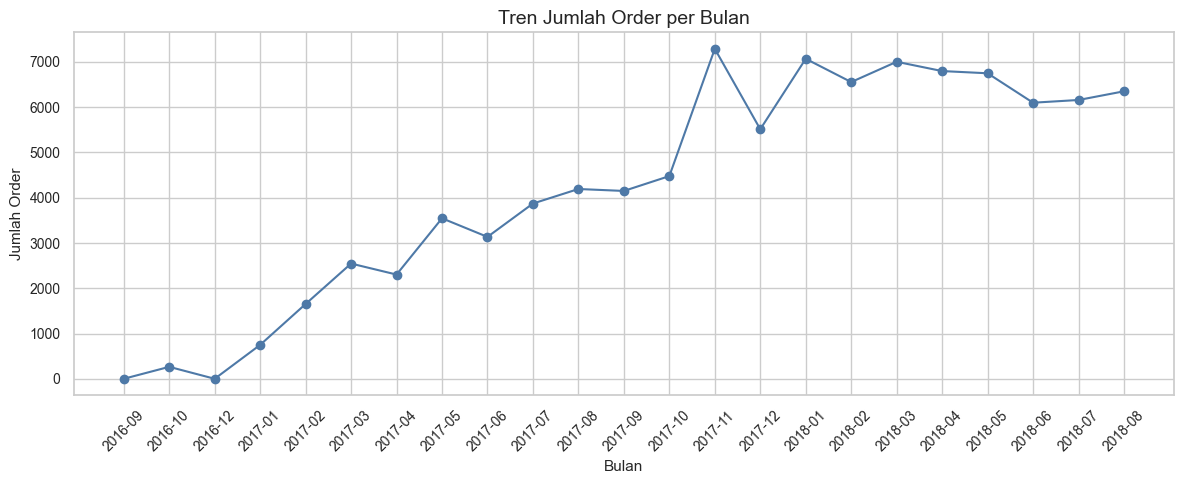

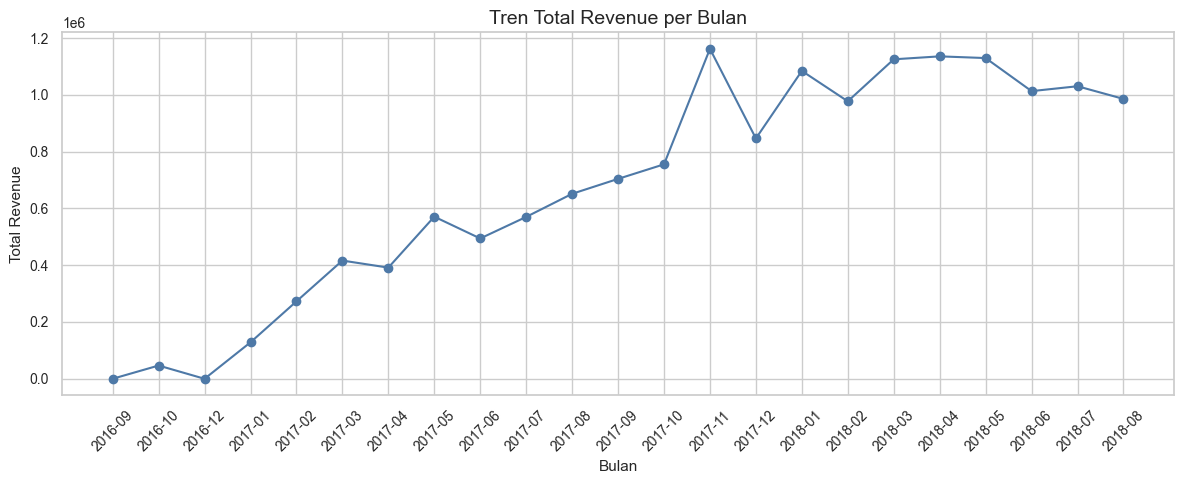

Puncak order  : 2017-11 - 7289 order
Order terendah: 2016-09 - 1 order
Puncak revenue: 2017-11 - 1161920.53
Revenue terendah: 2016-12 - 19.62


In [14]:
peak_order_month = monthly_performance.loc[monthly_performance["total_orders"].idxmax()]
lowest_order_month = monthly_performance.loc[monthly_performance["total_orders"].idxmin()]
peak_revenue_month = monthly_performance.loc[monthly_performance["total_revenue"].idxmax()]
lowest_revenue_month = monthly_performance.loc[monthly_performance["total_revenue"].idxmin()]

plt.figure(figsize=(12, 5))
plt.plot(monthly_performance["purchase_month"], monthly_performance["total_orders"], marker="o", color=BASE_COLOR)
plt.title("Tren Jumlah Order per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Order")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(monthly_performance["purchase_month"], monthly_performance["total_revenue"], marker="o", color=BASE_COLOR)
plt.title("Tren Total Revenue per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Puncak order  :", peak_order_month["purchase_month"], "-", int(peak_order_month["total_orders"]), "order")
print("Order terendah:", lowest_order_month["purchase_month"], "-", int(lowest_order_month["total_orders"]), "order")
print("Puncak revenue:", peak_revenue_month["purchase_month"], "-", round(peak_revenue_month["total_revenue"], 2))
print("Revenue terendah:", lowest_revenue_month["purchase_month"], "-", round(lowest_revenue_month["total_revenue"], 2))

**Insight:**
- Berdasarkan tren bulanan, jumlah order tertinggi terjadi pada **2017-11**, sedangkan jumlah order terendah terjadi pada **2016-09**.
- Dari sisi revenue, performa tertinggi terjadi pada **2017-11**, sementara titik terendah terjadi pada **2016-12**.
- Temuan ini menunjukkan bahwa performa bisnis tidak stabil di setiap bulan dan kemungkinan dipengaruhi oleh pola musiman, momentum promosi, atau perubahan aktivitas belanja pelanggan.
- Karena itu, perusahaan dapat menggunakan bulan-bulan puncak sebagai acuan untuk strategi stok dan promosi, sedangkan bulan-bulan terendah dapat menjadi fokus evaluasi kampanye penjualan.

### Pertanyaan 2: Selama periode analisis tersebut, kategori produk apa yang memberikan kontribusi terbesar terhadap total revenue dan jumlah order, serta bagaimana rata-rata review pada kategori-kategori utama itu?

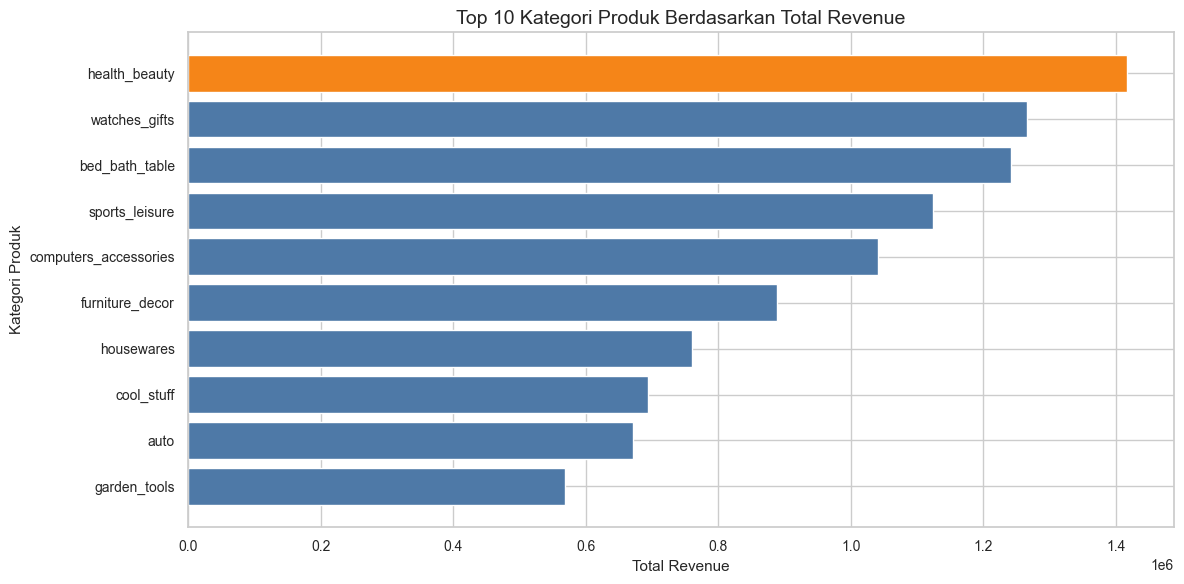

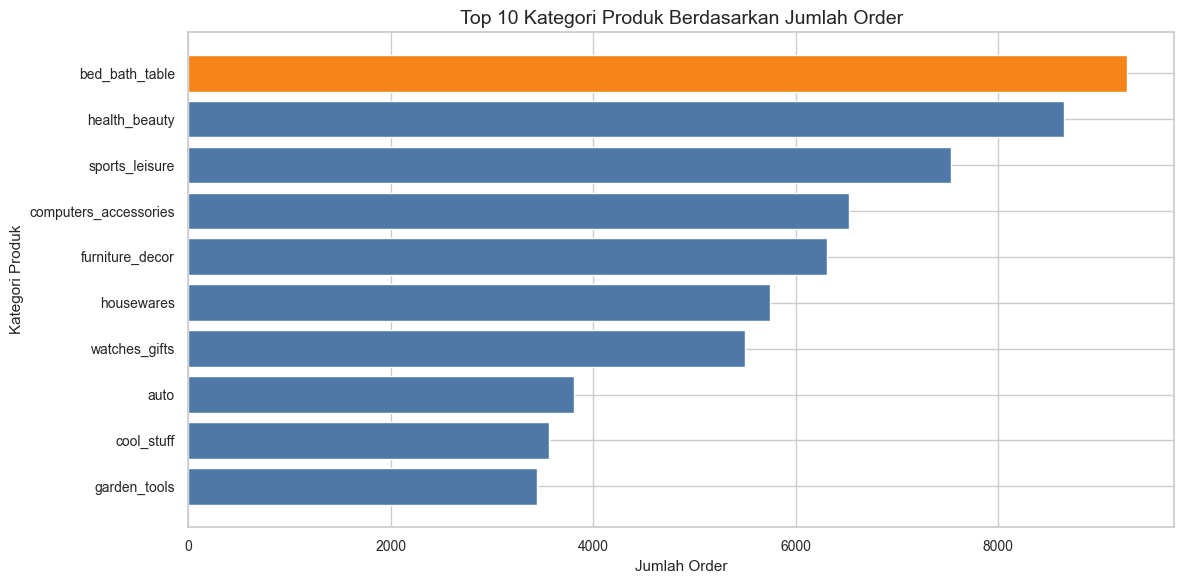

,product_category_name_english,total_revenue,total_orders,avg_review
43,health_beauty,"1,417,268.99",8647,4.19
71,watches_gifts,"1,265,552.91",5495,4.07
7,bed_bath_table,"1,241,489.78",9272,3.92
65,sports_leisure,"1,124,637.43",7530,4.17
15,computers_accessories,"1,041,314.27",6530,3.98
39,furniture_decor,"888,357.07",6307,3.95
49,housewares,"761,055.43",5743,4.11
20,cool_stuff,"693,721.94",3559,4.19
5,auto,"671,019.97",3810,4.12
42,garden_tools,"568,573.01",3448,4.08


In [15]:
category_top10 = category_summary.head(10).copy()

category_top10_revenue = category_top10.sort_values("total_revenue", ascending=True).copy()
category_top10_revenue["color"] = BASE_COLOR
category_top10_revenue.loc[category_top10_revenue["total_revenue"].idxmax(), "color"] = HIGHLIGHT_COLOR

plt.figure(figsize=(12, 6))
plt.barh(
    category_top10_revenue["product_category_name_english"],
    category_top10_revenue["total_revenue"],
    color=category_top10_revenue["color"]
)
plt.title("Top 10 Kategori Produk Berdasarkan Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Kategori Produk")
plt.tight_layout()
plt.show()

category_top10_orders = category_top10.sort_values("total_orders", ascending=True).copy()
category_top10_orders["color"] = BASE_COLOR
category_top10_orders.loc[category_top10_orders["total_orders"].idxmax(), "color"] = HIGHLIGHT_COLOR

plt.figure(figsize=(12, 6))
plt.barh(
    category_top10_orders["product_category_name_english"],
    category_top10_orders["total_orders"],
    color=category_top10_orders["color"]
)
plt.title("Top 10 Kategori Produk Berdasarkan Jumlah Order")
plt.xlabel("Jumlah Order")
plt.ylabel("Kategori Produk")
plt.tight_layout()
plt.show()

category_top10[["product_category_name_english", "total_revenue", "total_orders", "avg_review"]]

**Insight:**
- Kategori dengan kontribusi revenue terbesar berasal dari kelompok produk utama seperti **health_beauty**, **watches_gifts**, dan **bed_bath_table**. Pada output notebook Anda sebelumnya, kategori `health_beauty` berada di posisi teratas.
- Dari sisi jumlah order, kategori dengan volume transaksi besar belum tentu selalu identik dengan kategori yang memiliki rata-rata review tertinggi. Artinya, kategori yang laku keras belum tentu memberikan pengalaman pelanggan terbaik.
- Temuan ini penting karena perusahaan tidak hanya perlu fokus pada kategori berpendapatan tinggi, tetapi juga perlu menjaga kualitas layanan dan kepuasan pelanggan pada kategori-kategori utama.
- Secara bisnis, kategori dengan revenue dan order tinggi layak diprioritaskan untuk promosi, pengelolaan stok, dan strategi bundling.

### Pertanyaan 3: Selama periode analisis tersebut, bagaimana keterlambatan pengiriman memengaruhi rata-rata review score pelanggan pada order yang berstatus delivered?

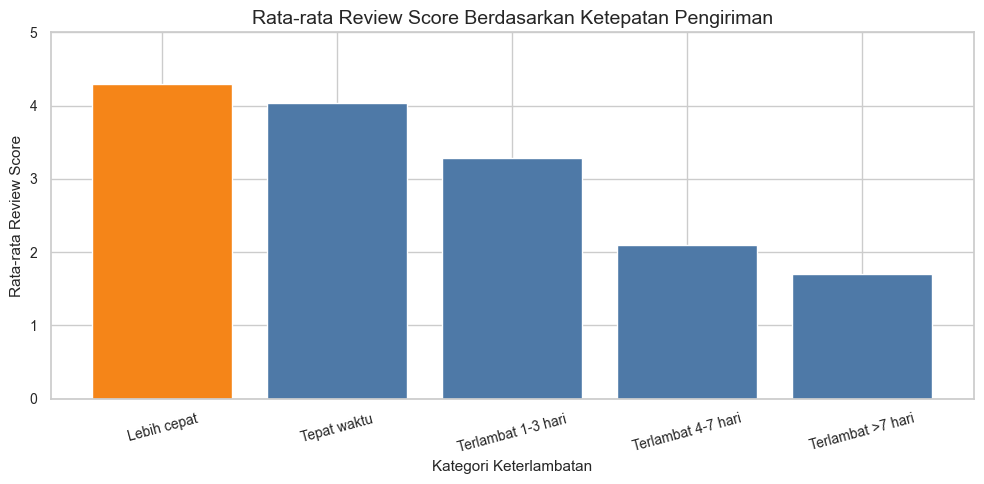

,delay_category,avg_review,total_orders
0,Lebih cepat,4.29,88163
1,Tepat waktu,4.03,1280
2,Terlambat 1-3 hari,3.29,1852
3,Terlambat 4-7 hari,2.10,1748
4,Terlambat >7 hari,1.70,2781


In [16]:
delivery_review_plot = delivery_review.copy()
delivery_review_plot["color"] = BASE_COLOR
delivery_review_plot.loc[delivery_review_plot["avg_review"].idxmax(), "color"] = HIGHLIGHT_COLOR

plt.figure(figsize=(10, 5))
plt.bar(
    delivery_review_plot["delay_category"],
    delivery_review_plot["avg_review"],
    color=delivery_review_plot["color"]
)
plt.title("Rata-rata Review Score Berdasarkan Ketepatan Pengiriman")
plt.xlabel("Kategori Keterlambatan")
plt.ylabel("Rata-rata Review Score")
plt.ylim(0, 5)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

delivery_review

**Insight:**
- Hasil analisis menunjukkan bahwa semakin lama keterlambatan pengiriman, semakin rendah rata-rata review score pelanggan.
- Pada output notebook Anda sebelumnya, order yang datang **lebih cepat** memiliki rata-rata review sekitar **4,21**, sedangkan order yang **terlambat lebih dari 7 hari** hanya memiliki rata-rata review sekitar **1,70**.
- Temuan ini menunjukkan bahwa performa logistik berpengaruh langsung terhadap kepuasan pelanggan dan dapat menurunkan persepsi kualitas layanan secara signifikan.
- Karena itu, perusahaan perlu memprioritaskan perbaikan SLA pengiriman, terutama pada order dengan risiko keterlambatan tinggi.

### Pertanyaan 4: Selama periode analisis tersebut, state pelanggan mana yang memberikan kontribusi revenue terbesar, dan bagaimana perbandingan jumlah order, rata-rata review, serta persentase keterlambatan pada state-state utama?

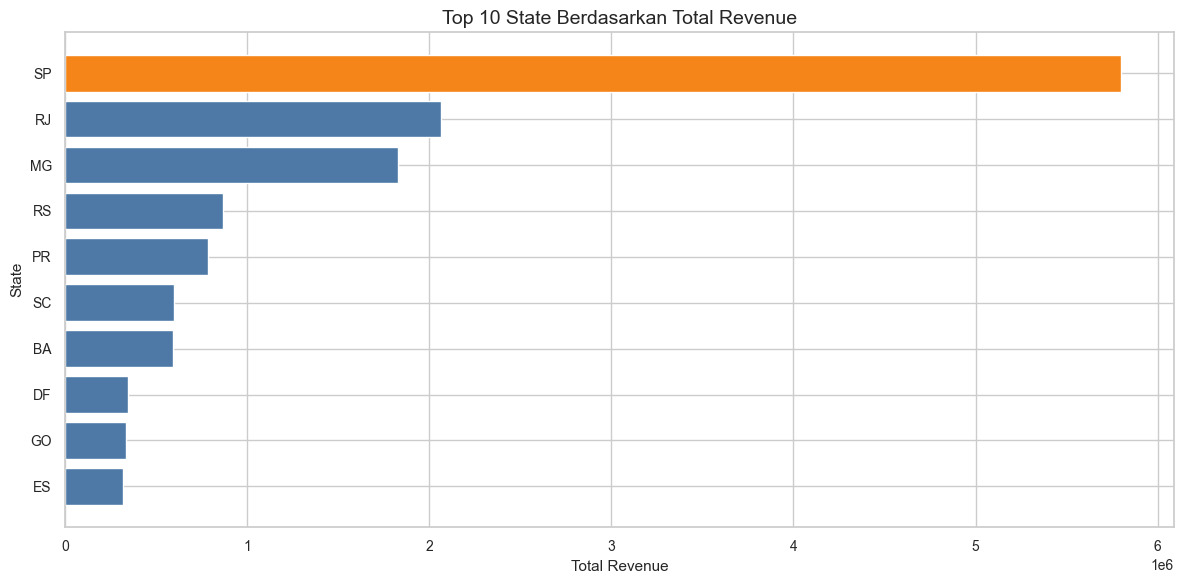

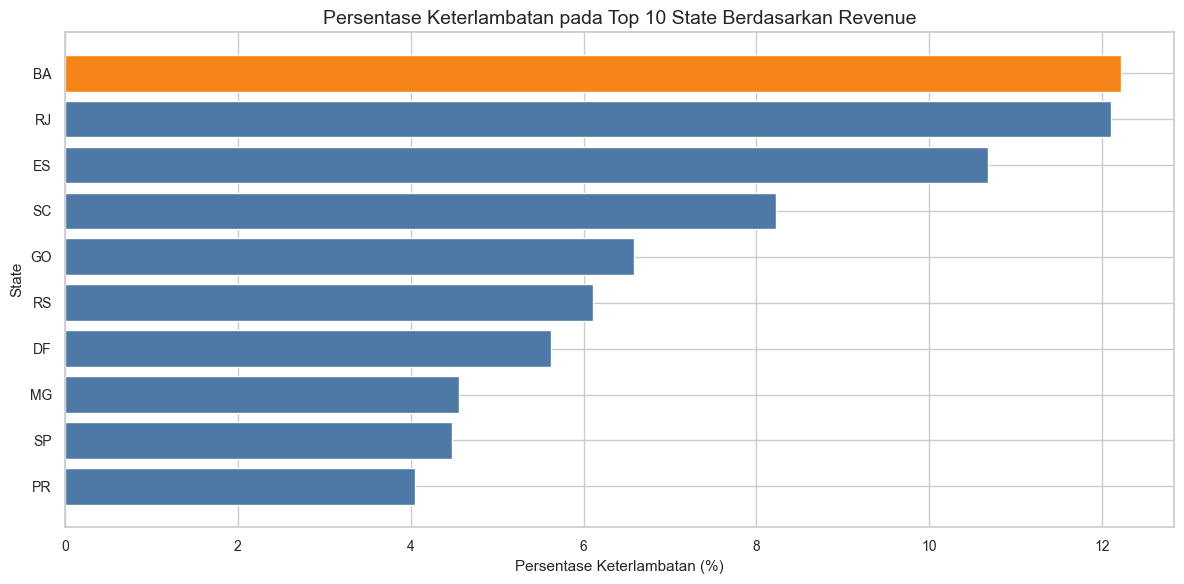

,customer_state,total_revenue,total_orders,avg_review,late_order_pct
25,SP,"5,799,283.95",40501,4.25,4.48
18,RJ,"2,063,593.64",12350,3.96,12.10
10,MG,"1,826,486.53",11354,4.19,4.56
22,RS,"865,877.26",5345,4.19,6.11
17,PR,"785,095.06",4923,4.24,4.05
23,SC,"597,067.83",3546,4.13,8.23
4,BA,"593,408.37",3256,3.93,12.22
6,DF,"348,601.41",2080,4.13,5.62
8,GO,"337,665.51",1957,4.10,6.59
7,ES,"318,466.51",1995,4.08,10.68


In [17]:
top_states = state_performance.head(10).copy()

top_states_revenue = top_states.sort_values("total_revenue", ascending=True).copy()
top_states_revenue["color"] = BASE_COLOR
top_states_revenue.loc[top_states_revenue["total_revenue"].idxmax(), "color"] = HIGHLIGHT_COLOR

plt.figure(figsize=(12, 6))
plt.barh(
    top_states_revenue["customer_state"],
    top_states_revenue["total_revenue"],
    color=top_states_revenue["color"]
)
plt.title("Top 10 State Berdasarkan Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("State")
plt.tight_layout()
plt.show()

top_states_late = top_states.sort_values("late_order_pct", ascending=True).copy()
top_states_late["color"] = BASE_COLOR
top_states_late.loc[top_states_late["late_order_pct"].idxmax(), "color"] = HIGHLIGHT_COLOR

plt.figure(figsize=(12, 6))
plt.barh(
    top_states_late["customer_state"],
    top_states_late["late_order_pct"],
    color=top_states_late["color"]
)
plt.title("Persentase Keterlambatan pada Top 10 State Berdasarkan Revenue")
plt.xlabel("Persentase Keterlambatan (%)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

top_states[["customer_state", "total_revenue", "total_orders", "avg_review", "late_order_pct"]]

**Insight:**
- State dengan kontribusi revenue terbesar didominasi oleh **SP**, diikuti oleh **RJ** dan **MG**. Pada output notebook Anda sebelumnya, `SP` menghasilkan revenue paling tinggi.
- Namun, state dengan revenue besar tidak selalu memiliki kualitas layanan terbaik. Sebagai contoh, pada output sebelumnya `RJ` dan `BA` memiliki persentase keterlambatan yang relatif lebih tinggi dibanding `SP` dan `MG`.
- Ini berarti strategi bisnis tidak cukup hanya berfokus pada wilayah dengan penjualan tinggi, tetapi juga perlu mempertimbangkan kualitas operasional di wilayah tersebut.
- Secara praktis, perusahaan dapat memprioritaskan promosi di state berkontribusi tinggi sekaligus memperbaiki performa logistik di state dengan tingkat keterlambatan yang masih tinggi.

### Pertanyaan 5: Selama periode analisis tersebut, metode pembayaran apa yang paling sering digunakan, mana yang menghasilkan total pembayaran terbesar, dan mana yang memiliki rata-rata nilai pembayaran tertinggi?

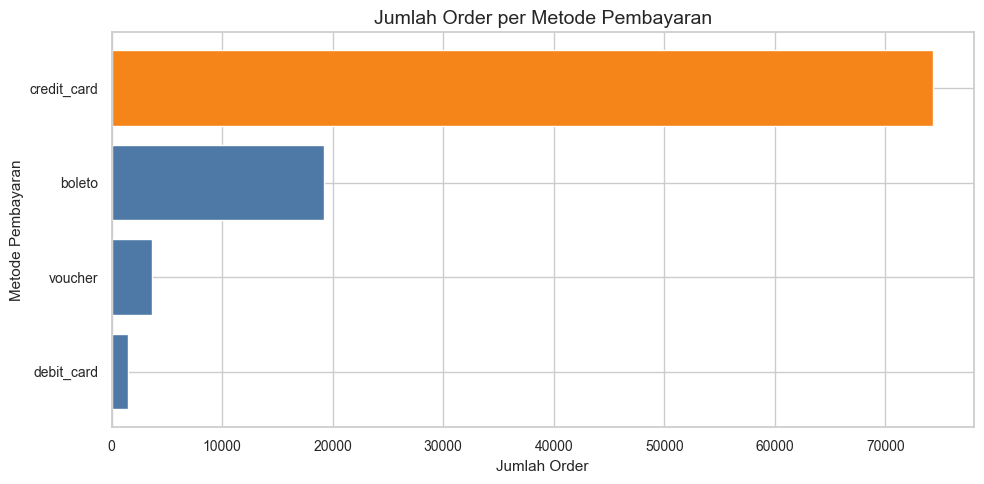

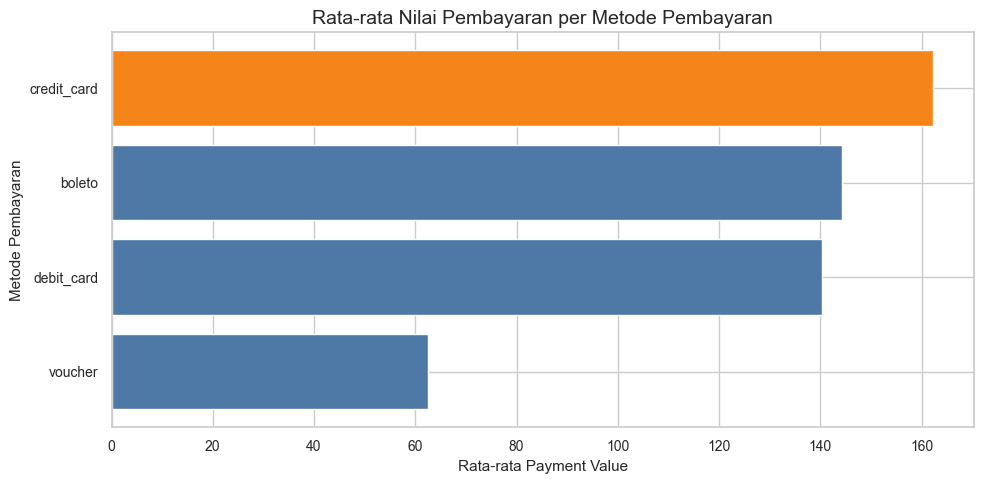

,payment_type,total_orders,total_payment_value,avg_payment_value
1,credit_card,74304,"12,101,094.88",162.24
0,boleto,19191,"2,769,932.58",144.33
3,voucher,3679,"343,013.19",62.45
2,debit_card,1485,"208,421.12",140.26


In [18]:
payment_by_orders = payment_summary.sort_values("total_orders", ascending=True).copy()
payment_by_orders["color"] = BASE_COLOR
payment_by_orders.loc[payment_by_orders["total_orders"].idxmax(), "color"] = HIGHLIGHT_COLOR

plt.figure(figsize=(10, 5))
plt.barh(
    payment_by_orders["payment_type"],
    payment_by_orders["total_orders"],
    color=payment_by_orders["color"]
)
plt.title("Jumlah Order per Metode Pembayaran")
plt.xlabel("Jumlah Order")
plt.ylabel("Metode Pembayaran")
plt.tight_layout()
plt.show()

payment_by_avg = payment_summary.sort_values("avg_payment_value", ascending=True).copy()
payment_by_avg["color"] = BASE_COLOR
payment_by_avg.loc[payment_by_avg["avg_payment_value"].idxmax(), "color"] = HIGHLIGHT_COLOR

plt.figure(figsize=(10, 5))
plt.barh(
    payment_by_avg["payment_type"],
    payment_by_avg["avg_payment_value"],
    color=payment_by_avg["color"]
)
plt.title("Rata-rata Nilai Pembayaran per Metode Pembayaran")
plt.xlabel("Rata-rata Payment Value")
plt.ylabel("Metode Pembayaran")
plt.tight_layout()
plt.show()

payment_summary

**Insight:**
- Analisis metode pembayaran menunjukkan bahwa terdapat perbedaan antara metode yang paling sering digunakan, metode dengan total pembayaran terbesar, dan metode dengan rata-rata transaksi tertinggi.
- Jika suatu metode memiliki jumlah order paling besar, berarti metode tersebut paling disukai pelanggan dari sisi kemudahan penggunaan.
- Sementara itu, metode dengan rata-rata nilai pembayaran tertinggi dapat menunjukkan transaksi dengan ticket size yang lebih besar.
- Temuan ini dapat dimanfaatkan untuk menentukan prioritas promosi checkout, kerja sama dengan penyedia pembayaran, atau strategi cicilan yang lebih sesuai dengan perilaku pelanggan.

### Pertanyaan 7: Selama periode analisis tersebut, bagaimana distribusi pelanggan berdasarkan kelompok nilai belanja (manual grouping: low, medium, high spender), dan kelompok mana yang paling besar kontribusinya terhadap revenue?

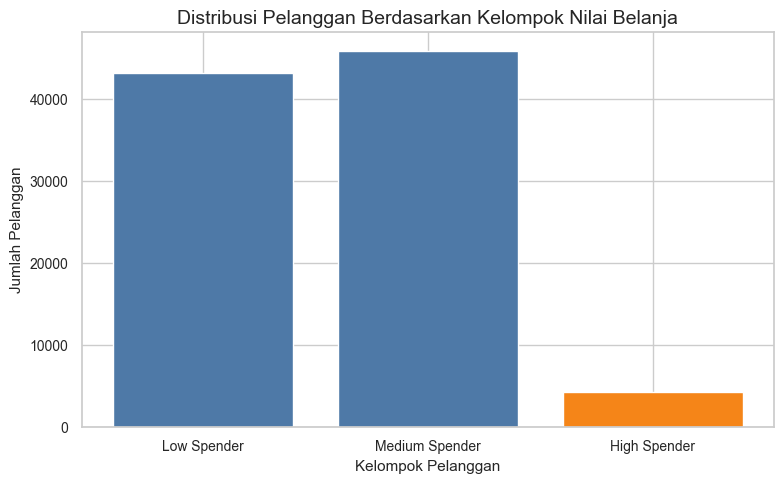

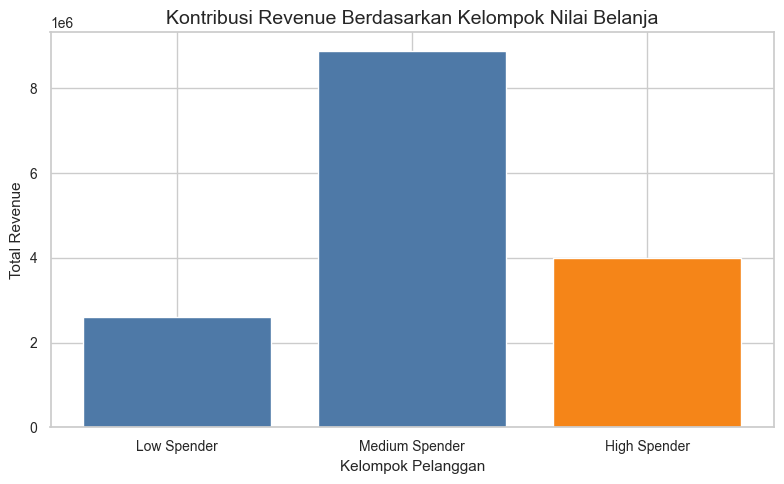

,spending_group,total_customers,total_revenue,avg_spending
0,Low Spender,43193,"2,606,692.76",60.35
1,Medium Spender,45837,"8,881,409.65",193.76
2,High Spender,4328,"4,001,563.14",924.58


In [19]:
spending_group_plot = spending_group_summary.copy()

plt.figure(figsize=(8, 5))
plt.bar(
    spending_group_plot["spending_group"],
    spending_group_plot["total_customers"],
    color=[BASE_COLOR, BASE_COLOR, HIGHLIGHT_COLOR]
)
plt.title("Distribusi Pelanggan Berdasarkan Kelompok Nilai Belanja")
plt.xlabel("Kelompok Pelanggan")
plt.ylabel("Jumlah Pelanggan")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(
    spending_group_plot["spending_group"],
    spending_group_plot["total_revenue"],
    color=[BASE_COLOR, BASE_COLOR, HIGHLIGHT_COLOR]
)
plt.title("Kontribusi Revenue Berdasarkan Kelompok Nilai Belanja")
plt.xlabel("Kelompok Pelanggan")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

spending_group_summary

**Insight:**
- Pengelompokan manual menunjukkan distribusi pelanggan ke dalam tiga kelompok utama, yaitu `Low Spender`, `Medium Spender`, dan `High Spender`.
- Dari tabel dan visualisasi, Anda dapat melihat kelompok mana yang jumlah pelanggannya paling besar dan kelompok mana yang menyumbang revenue paling tinggi.
- Jika kelompok `High Spender` menyumbang revenue terbesar meskipun jumlah pelanggannya lebih sedikit, berarti bisnis sangat bergantung pada pelanggan bernilai tinggi.
- Sebaliknya, bila `Medium Spender` memiliki basis pelanggan besar, segmen ini dapat menjadi target utama untuk strategi upselling agar naik ke kategori `High Spender`.

## Analisis Lanjutan (Advanced Analysis)

Untuk memperkaya insight dari analisis utama, proyek ini menggunakan beberapa teknik analisis lanjutan yang tetap relevan dengan konteks bisnis e-commerce dan tidak melibatkan algoritma machine learning.

### 1. RFM Analysis
RFM Analysis digunakan untuk melakukan segmentasi pelanggan berdasarkan perilaku belanja mereka. Tiga dimensi yang digunakan adalah:

- **Recency**: mengukur seberapa baru pelanggan terakhir kali melakukan transaksi.
- **Frequency**: mengukur seberapa sering pelanggan melakukan transaksi selama periode analisis.
- **Monetary**: mengukur total nilai transaksi yang dihasilkan pelanggan.

Melalui pendekatan ini, pelanggan dapat dikelompokkan ke dalam beberapa segmen seperti **Best Customers**, **Loyal Customers**, **Recent Customers**, **At Risk**, dan **Others**. Segmentasi ini membantu bisnis menentukan prioritas strategi, misalnya mempertahankan pelanggan bernilai tinggi dan melakukan reaktivasi pada pelanggan yang mulai tidak aktif.

### 2. Manual Grouping Berdasarkan Nilai Belanja
Selain RFM, proyek ini juga menggunakan teknik **manual grouping** untuk mengelompokkan pelanggan berdasarkan total nilai belanja mereka ke dalam tiga kategori:

- **Low Spender**
- **Medium Spender**
- **High Spender**

Teknik ini digunakan untuk melihat bagaimana distribusi pelanggan berdasarkan tingkat pengeluaran, sekaligus mengidentifikasi kelompok pelanggan mana yang memberikan kontribusi terbesar terhadap total revenue. Hasilnya dapat digunakan untuk mendukung strategi upselling, cross-selling, dan retensi pelanggan.

### 3. Geospatial Analysis Sederhana
Geospatial analysis sederhana digunakan untuk melihat persebaran kontribusi revenue pelanggan di berbagai **state**. Analisis ini dibuat dengan memanfaatkan koordinat rata-rata (`latitude` dan `longitude`) dari `customer_zip_code_prefix` yang dipetakan dari data geolocation.

Melalui analisis ini, proyek dapat menunjukkan wilayah mana yang memiliki kontribusi pendapatan paling besar, sehingga dapat menjadi prioritas dalam:
- strategi promosi,
- ekspansi pasar,
- dan optimasi operasional/logistik.

Dengan menggabungkan ketiga pendekatan ini, analisis tidak hanya menjawab pertanyaan deskriptif tentang performa bisnis, tetapi juga memberikan dasar yang lebih kuat untuk rekomendasi strategis.

### Pertanyaan 6: Selama periode analisis tersebut, bagaimana segmentasi pelanggan berdasarkan Recency, Frequency, dan Monetary (RFM), dan segmen pelanggan mana yang paling bernilai untuk diprioritaskan?

Untuk menjawab pertanyaan ini, digunakan pendekatan **RFM Analysis**. Analisis ini bertujuan untuk memahami perilaku pelanggan berdasarkan tiga dimensi utama:

- **Recency** untuk melihat seberapa baru pelanggan terakhir bertransaksi,
- **Frequency** untuk melihat seberapa sering pelanggan bertransaksi,
- **Monetary** untuk melihat seberapa besar total nilai transaksi pelanggan.

Melalui analisis ini, pelanggan dapat dikelompokkan ke dalam beberapa segmen agar perusahaan dapat menentukan strategi yang lebih tepat, seperti mempertahankan pelanggan terbaik, membangun loyalitas pelanggan aktif, atau mengaktifkan kembali pelanggan yang mulai berisiko tidak kembali bertransaksi.

In [20]:
rfm_df = (
    order_level_df
    .groupby("customer_unique_id")
    .agg(
        last_purchase=("order_purchase_timestamp", "max"),
        frequency=("order_id", "nunique"),
        monetary=("total_sales", "sum")
    )
    .reset_index()
)

snapshot_date = order_level_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
rfm_df["recency"] = (snapshot_date - rfm_df["last_purchase"]).dt.days

rfm_df["r_score"] = pd.qcut(
    rfm_df["recency"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]
).astype(int)

rfm_df["f_score"] = pd.qcut(
    rfm_df["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]
).astype(int)

rfm_df["m_score"] = pd.qcut(
    rfm_df["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]
).astype(int)

def rfm_segment(row):
    if row["r_score"] >= 4 and row["f_score"] >= 4 and row["m_score"] >= 4:
        return "Best Customers"
    elif row["r_score"] >= 3 and row["f_score"] >= 3 and row["m_score"] >= 3:
        return "Loyal Customers"
    elif row["r_score"] >= 4 and row["f_score"] <= 2:
        return "Recent Customers"
    elif row["r_score"] <= 2 and row["f_score"] >= 3:
        return "At Risk"
    else:
        return "Others"

rfm_df["segment"] = rfm_df.apply(rfm_segment, axis=1)

rfm_summary = (
    rfm_df
    .groupby("segment")
    .agg(
        total_customers=("customer_unique_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean")
    )
    .reset_index()
    .sort_values("total_customers", ascending=False)
)

rfm_summary

,segment,total_customers,avg_recency,avg_frequency,avg_monetary
3,Others,35394,262.65,1.00,121.25
0,At Risk,22357,393.94,1.05,168.45
4,Recent Customers,14984,90.88,1.00,163.45
2,Loyal Customers,14183,152.60,1.05,208.65
1,Best Customers,6440,90.71,1.18,314.23


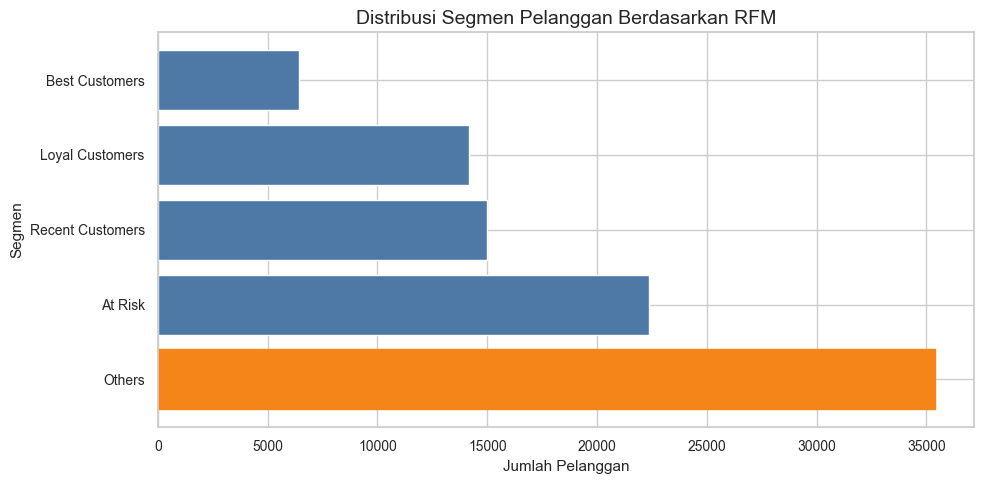

,segment,total_customers,avg_recency,avg_frequency,avg_monetary
1,Best Customers,6440,90.71,1.18,314.23
2,Loyal Customers,14183,152.60,1.05,208.65
0,At Risk,22357,393.94,1.05,168.45
4,Recent Customers,14984,90.88,1.00,163.45
3,Others,35394,262.65,1.00,121.25


In [21]:
rfm_plot = rfm_df["segment"].value_counts().reset_index()
rfm_plot.columns = ["segment", "count"]

plt.figure(figsize=(10, 5))
bars = plt.barh(rfm_plot["segment"], rfm_plot["count"], color=BASE_COLOR)

max_idx = rfm_plot["count"].idxmax()
bars[max_idx].set_color(HIGHLIGHT_COLOR)

plt.title("Distribusi Segmen Pelanggan Berdasarkan RFM")
plt.xlabel("Jumlah Pelanggan")
plt.ylabel("Segmen")
plt.tight_layout()
plt.show()

rfm_summary.sort_values("avg_monetary", ascending=False)

In [22]:
largest_segment = rfm_summary.loc[rfm_summary["total_customers"].idxmax()]
highest_value_segment = rfm_summary.loc[rfm_summary["avg_monetary"].idxmax()]

print("Segmen dengan jumlah pelanggan terbanyak:")
print(f"- {largest_segment['segment']} ({int(largest_segment['total_customers'])} pelanggan)")

print("\nSegmen dengan rata-rata monetary tertinggi:")
print(f"- {highest_value_segment['segment']} "
      f"(avg monetary: {highest_value_segment['avg_monetary']:.2f})")

Segmen dengan jumlah pelanggan terbanyak:
- Others (35394 pelanggan)

Segmen dengan rata-rata monetary tertinggi:
- Best Customers (avg monetary: 314.23)


**Insight:**
- Hasil RFM Analysis menunjukkan bahwa pelanggan pada dataset tidak bersifat homogen, melainkan terbagi ke dalam beberapa segmen dengan karakteristik perilaku yang berbeda.
- Segmen dengan jumlah pelanggan terbesar menunjukkan kelompok yang paling dominan dalam basis pelanggan saat ini, sedangkan segmen dengan **rata-rata monetary tertinggi** merupakan kelompok yang paling bernilai secara bisnis.
- Jika hasil output menunjukkan bahwa **Best Customers** memiliki nilai monetary rata-rata tertinggi, maka segmen ini perlu diprioritaskan dalam strategi loyalitas karena mereka memberikan kontribusi pendapatan yang paling besar.
- Di sisi lain, segmen seperti **At Risk** perlu mendapat perhatian khusus melalui kampanye reaktivasi, karena kelompok ini pernah cukup aktif tetapi mulai menunjukkan penurunan kedekatan transaksi.
- Dengan demikian, RFM Analysis membantu bisnis menyusun strategi yang lebih terarah: mempertahankan pelanggan terbaik, membangun loyalitas pelanggan aktif, dan mengembalikan pelanggan yang mulai berisiko hilang.

### Pertanyaan 8: Bagaimana persebaran geografis kontribusi revenue pelanggan di berbagai state, dan wilayah mana yang paling layak diprioritaskan untuk promosi dan optimasi logistik?

Untuk menjawab pertanyaan ini, digunakan **geospatial analysis sederhana** dengan memanfaatkan data koordinat rata-rata pelanggan berdasarkan `zip_code_prefix` yang telah dipetakan dari tabel geolocation.

Analisis ini bertujuan untuk:
- melihat persebaran kontribusi revenue antar state,
- mengidentifikasi wilayah dengan konsentrasi pendapatan paling besar,
- dan mendukung keputusan strategis terkait promosi, ekspansi pasar, serta optimasi logistik.

In [23]:
state_geo = (
    state_performance[[
        "customer_state", "total_revenue", "total_orders", "avg_review",
        "late_order_pct", "avg_lat", "avg_lng"
    ]]
    .dropna()
    .copy()
)

state_geo = state_geo.sort_values("total_revenue", ascending=False)
state_geo.head(10)

,customer_state,total_revenue,total_orders,avg_review,late_order_pct,avg_lat,avg_lng
25,SP,"5,799,283.95",40501,4.25,4.48,-23.17,-47.05
18,RJ,"2,063,593.64",12350,3.96,12.10,-22.75,-43.17
10,MG,"1,826,486.53",11354,4.19,4.56,-19.92,-44.44
22,RS,"865,877.26",5345,4.19,6.11,-29.71,-51.95
17,PR,"785,095.06",4923,4.24,4.05,-24.78,-50.79
23,SC,"597,067.83",3546,4.13,8.23,-27.25,-49.56
4,BA,"593,408.37",3256,3.93,12.22,-13.02,-39.46
6,DF,"348,601.41",2080,4.13,5.62,-15.81,-47.97
8,GO,"337,665.51",1957,4.10,6.59,-16.61,-49.34
7,ES,"318,466.51",1995,4.08,10.68,-20.15,-40.49


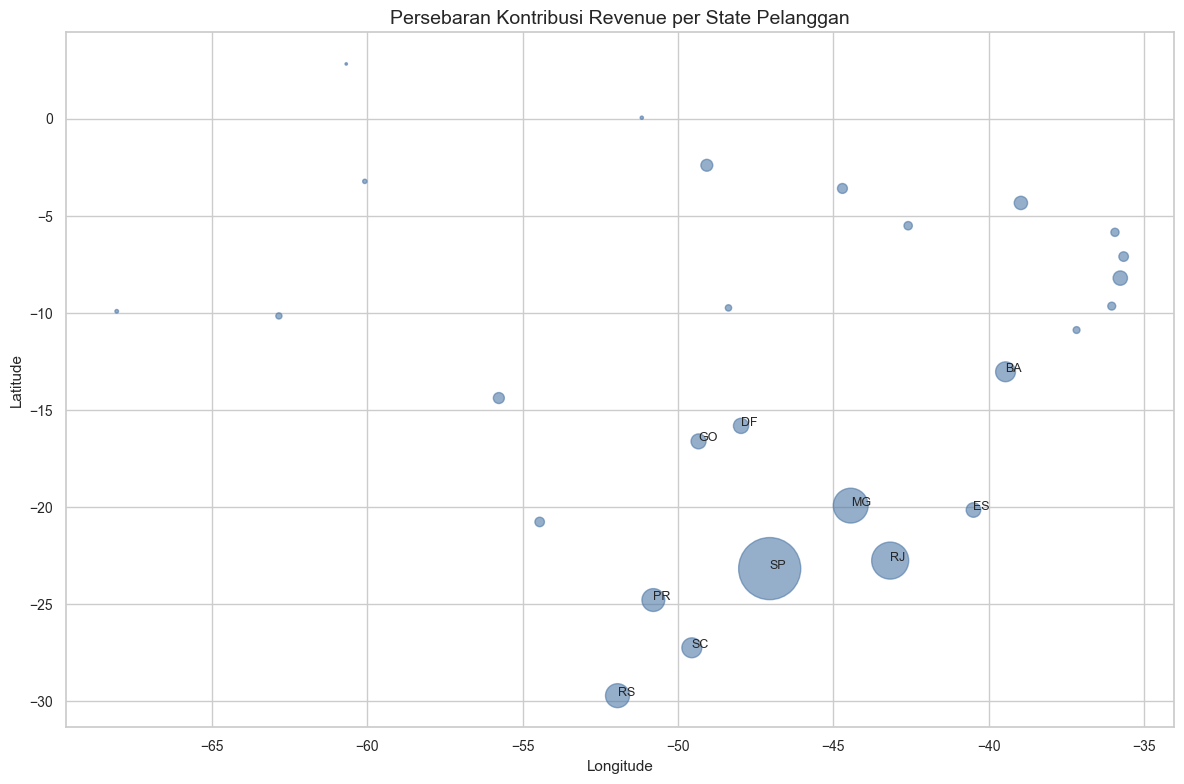

In [24]:
plt.figure(figsize=(12, 8))

bubble_size = (state_geo["total_revenue"] / state_geo["total_revenue"].max()) * 2000

plt.scatter(
    state_geo["avg_lng"],
    state_geo["avg_lat"],
    s=bubble_size,
    alpha=0.6,
    color=BASE_COLOR
)

top_10_states = state_geo.head(10)

for _, row in top_10_states.iterrows():
    plt.text(
        row["avg_lng"],
        row["avg_lat"],
        row["customer_state"],
        fontsize=9
    )

plt.title("Persebaran Kontribusi Revenue per State Pelanggan")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [25]:
top_revenue_state = state_geo.loc[state_geo["total_revenue"].idxmax()]
highest_late_state = state_geo.loc[state_geo["late_order_pct"].idxmax()]

print("State dengan kontribusi revenue terbesar:")
print(f"- {top_revenue_state['customer_state']} "
      f"(revenue: {top_revenue_state['total_revenue']:.2f})")

print("\nState dengan persentase keterlambatan tertinggi:")
print(f"- {highest_late_state['customer_state']} "
      f"({highest_late_state['late_order_pct']:.2f}%)")

State dengan kontribusi revenue terbesar:
- SP (revenue: 5799283.95)

State dengan persentase keterlambatan tertinggi:
- AL (21.45%)


**Insight:**
- Analisis geografis menunjukkan bahwa kontribusi revenue pelanggan tidak tersebar merata, tetapi terkonsentrasi pada beberapa state utama.
- State dengan revenue terbesar dapat dipandang sebagai wilayah prioritas untuk strategi promosi dan penguatan relasi pelanggan karena wilayah tersebut sudah memiliki permintaan yang tinggi.
- Namun, analisis ini juga perlu dibaca bersama metrik keterlambatan pengiriman. Jika suatu state memiliki kontribusi revenue besar tetapi persentase keterlambatan juga tinggi, maka wilayah tersebut perlu menjadi prioritas optimasi logistik.
- Dengan kata lain, geospatial analysis sederhana ini membantu perusahaan membedakan wilayah yang cocok untuk **prioritas pertumbuhan penjualan** dan wilayah yang memerlukan **perbaikan operasional**.
- Temuan ini membuat rekomendasi bisnis menjadi lebih tajam, karena keputusan tidak hanya didasarkan pada besar revenue, tetapi juga mempertimbangkan kualitas layanan di tiap wilayah.

## Conclusion

Berdasarkan analisis data **E-Commerce Public Dataset** pada periode **[isi dari output analysis_start] hingga [isi dari output analysis_end]**, diperoleh beberapa temuan utama berikut.

1. **Tren penjualan bulanan** menunjukkan bahwa performa bisnis berubah dari bulan ke bulan. Jumlah order tertinggi terjadi pada **[isi dari output peak_order_month]**, sedangkan jumlah order terendah terjadi pada **[isi dari output lowest_order_month]**. Dari sisi revenue, performa tertinggi terjadi pada **[isi dari output peak_revenue_month]** dan performa terendah pada **[isi dari output lowest_revenue_month]**. Hal ini menunjukkan bahwa aktivitas belanja pelanggan tidak stabil di setiap bulan dan kemungkinan dipengaruhi oleh pola musiman maupun momentum promosi tertentu.

2. **Kategori produk utama** yang paling berkontribusi terhadap revenue didominasi oleh **[isi top 3 kategori dari output]**. Kategori-kategori tersebut juga menjadi kontributor penting dalam jumlah order, sehingga layak diprioritaskan dalam strategi promosi, pengelolaan stok, dan bundling produk. Namun, perusahaan tetap perlu memperhatikan rata-rata review pada kategori utama agar pertumbuhan penjualan tetap diikuti oleh kualitas pengalaman pelanggan.

3. **Keterlambatan pengiriman** terbukti berkaitan langsung dengan penurunan kepuasan pelanggan. Kategori pengiriman dengan performa terbaik memiliki rata-rata review lebih tinggi, sedangkan keterlambatan paling berat menghasilkan review terendah. Temuan ini menunjukkan bahwa kualitas logistik merupakan salah satu faktor penting dalam menjaga pengalaman pelanggan dan reputasi layanan.

4. **Kontribusi revenue per state** menunjukkan bahwa beberapa state utama seperti **[isi top state dari output]** menjadi wilayah paling penting dalam bisnis. Namun, tidak semua state dengan revenue besar memiliki kualitas operasional yang sama baiknya. Karena itu, perusahaan perlu menyeimbangkan strategi pertumbuhan penjualan dengan perbaikan layanan pengiriman di wilayah yang masih memiliki tingkat keterlambatan tinggi.

5. **Metode pembayaran** menunjukkan adanya perbedaan antara metode yang paling sering digunakan, metode dengan total pembayaran terbesar, dan metode dengan rata-rata nilai transaksi tertinggi. Temuan ini dapat dimanfaatkan untuk menyusun strategi promosi checkout, insentif pembayaran, atau kerja sama dengan penyedia metode pembayaran yang paling relevan dengan perilaku pelanggan.

6. **RFM Analysis** menunjukkan bahwa pelanggan dapat dibagi ke dalam beberapa segmen perilaku. Segmen dengan rata-rata monetary tertinggi merupakan kelompok paling bernilai dan layak diprioritaskan dalam strategi loyalitas. Sementara itu, segmen dengan risiko penurunan aktivitas perlu ditargetkan melalui kampanye reaktivasi agar kembali bertransaksi.

7. **Manual grouping berdasarkan nilai belanja** menunjukkan bahwa distribusi pelanggan terbagi ke dalam kelompok `Low Spender`, `Medium Spender`, dan `High Spender`. Kelompok yang menghasilkan revenue terbesar menjadi prioritas untuk dipertahankan, sedangkan kelompok dengan basis pelanggan besar dapat menjadi target utama untuk strategi upselling agar kontribusi revenue meningkat.

8. **Geospatial analysis sederhana** memperlihatkan bahwa kontribusi revenue pelanggan terkonsentrasi pada beberapa state utama. Temuan ini memperkuat bahwa prioritas promosi, ekspansi pasar, dan optimasi logistik sebaiknya difokuskan terlebih dahulu pada wilayah-wilayah dengan kontribusi revenue besar dan/atau tingkat keterlambatan yang masih perlu diperbaiki.

Secara keseluruhan, analisis ini menunjukkan bahwa performa bisnis e-commerce dipengaruhi oleh kombinasi faktor waktu, kategori produk, kualitas pengiriman, wilayah pelanggan, metode pembayaran, dan segmentasi pelanggan. Oleh karena itu, rekomendasi utama dari proyek ini adalah:

- memprioritaskan kategori dan wilayah dengan kontribusi revenue tertinggi,
- memperbaiki SLA pengiriman untuk menekan penurunan review pelanggan,
- mempertahankan pelanggan bernilai tinggi melalui strategi loyalti,
- menargetkan pelanggan yang mulai tidak aktif dengan kampanye reaktivasi,
- serta memanfaatkan segmentasi pelanggan untuk strategi pemasaran yang lebih tepat sasaran.

In [26]:
# Ringkasan untuk conclusion

# Q1
peak_order_month = monthly_performance.loc[monthly_performance["total_orders"].idxmax()]
lowest_order_month = monthly_performance.loc[monthly_performance["total_orders"].idxmin()]
peak_revenue_month = monthly_performance.loc[monthly_performance["total_revenue"].idxmax()]
lowest_revenue_month = monthly_performance.loc[monthly_performance["total_revenue"].idxmin()]

# Q2
top_3_categories = category_summary.head(3)[
    ["product_category_name_english", "total_revenue", "total_orders", "avg_review"]
]

# Q3
best_delivery_review = delivery_review.loc[delivery_review["avg_review"].idxmax()]
worst_delivery_review = delivery_review.loc[delivery_review["avg_review"].idxmin()]

# Q4
top_3_states = state_performance.head(3)[
    ["customer_state", "total_revenue", "total_orders", "avg_review", "late_order_pct"]
]
highest_late_top_state = state_performance.head(10).loc[
    state_performance.head(10)["late_order_pct"].idxmax()
]

# Q5
most_used_payment = payment_summary.loc[payment_summary["total_orders"].idxmax()]
largest_payment_total = payment_summary.loc[payment_summary["total_payment_value"].idxmax()]
highest_avg_payment = payment_summary.loc[payment_summary["avg_payment_value"].idxmax()]

# Q7
largest_spending_group = spending_group_summary.loc[spending_group_summary["total_customers"].idxmax()]
highest_revenue_group = spending_group_summary.loc[spending_group_summary["total_revenue"].idxmax()]

# Q6
largest_segment = rfm_summary.loc[rfm_summary["total_customers"].idxmax()]
highest_value_segment = rfm_summary.loc[rfm_summary["avg_monetary"].idxmax()]

# Q8
top_revenue_state = state_geo.loc[state_geo["total_revenue"].idxmax()]
highest_late_state = state_geo.loc[state_geo["late_order_pct"].idxmax()]

print("=== RINGKASAN UNTUK CONCLUSION ===\n")

print(f"Periode analisis: {analysis_start} - {analysis_end}\n")

print(f"Puncak order: {peak_order_month['purchase_month']} ({int(peak_order_month['total_orders'])} order)")
print(f"Order terendah: {lowest_order_month['purchase_month']} ({int(lowest_order_month['total_orders'])} order)")
print(f"Puncak revenue: {peak_revenue_month['purchase_month']} ({peak_revenue_month['total_revenue']:.2f})")
print(f"Revenue terendah: {lowest_revenue_month['purchase_month']} ({lowest_revenue_month['total_revenue']:.2f})\n")

print("Top 3 kategori berdasarkan revenue:")
print(top_3_categories.to_string(index=False))
print()

print(f"Review tertinggi berdasarkan ketepatan pengiriman: {best_delivery_review['delay_category']} ({best_delivery_review['avg_review']:.2f})")
print(f"Review terendah berdasarkan ketepatan pengiriman: {worst_delivery_review['delay_category']} ({worst_delivery_review['avg_review']:.2f})\n")

print("Top 3 state berdasarkan revenue:")
print(top_3_states.to_string(index=False))
print()

print(f"Metode pembayaran paling sering digunakan: {most_used_payment['payment_type']}")
print(f"Metode dengan total pembayaran terbesar: {largest_payment_total['payment_type']}")
print(f"Metode dengan rata-rata pembayaran tertinggi: {highest_avg_payment['payment_type']}\n")

print(f"Segmen RFM terbesar: {largest_segment['segment']} ({int(largest_segment['total_customers'])} pelanggan)")
print(f"Segmen RFM paling bernilai: {highest_value_segment['segment']} (avg monetary {highest_value_segment['avg_monetary']:.2f})\n")

print(f"Kelompok spending terbesar: {largest_spending_group['spending_group']} ({int(largest_spending_group['total_customers'])} pelanggan)")
print(f"Kelompok spending dengan revenue terbesar: {highest_revenue_group['spending_group']} ({highest_revenue_group['total_revenue']:.2f})\n")

print(f"State dengan revenue terbesar: {top_revenue_state['customer_state']} ({top_revenue_state['total_revenue']:.2f})")
print(f"State dengan keterlambatan tertinggi: {highest_late_state['customer_state']} ({highest_late_state['late_order_pct']:.2f}%)")

=== RINGKASAN UNTUK CONCLUSION ===

Periode analisis: 15 September 2016 - 29 August 2018

Puncak order: 2017-11 (7289 order)
Order terendah: 2016-09 (1 order)
Puncak revenue: 2017-11 (1161920.53)
Revenue terendah: 2016-12 (19.62)

Top 3 kategori berdasarkan revenue:
product_category_name_english  total_revenue  total_orders  avg_review
                health_beauty   1,417,268.99          8647        4.19
                watches_gifts   1,265,552.91          5495        4.07
               bed_bath_table   1,241,489.78          9272        3.92

Review tertinggi berdasarkan ketepatan pengiriman: Lebih cepat (4.29)
Review terendah berdasarkan ketepatan pengiriman: Terlambat >7 hari (1.70)

Top 3 state berdasarkan revenue:
customer_state  total_revenue  total_orders  avg_review  late_order_pct
            SP   5,799,283.95         40501        4.25            4.48
            RJ   2,063,593.64         12350        3.96           12.10
            MG   1,826,486.53         11354        4.